# Лабораторная работа 10

Тема: **Рекуррентные сети (LSTM/GRU) для классификации текстов в PyTorch**  
Цель: реализовать полный цикл решения задачи бинарной классификации текстов с помощью LSTM‑модели: от токенизации и построения словаря до обучения, валидации и анализа ошибок.

> Этот ноутбук оформлен как практическое задание.  
> Код даёт каркас, но основная часть баллов — за ваши собственные эксперименты и ваши пояснения.  
> Если вы попытаетесь автоматически сгенерировать весь текст отчёта, это будет заметно по стилю и несоответствию реальным графикам и числам.


## 1. Ваше исходное понимание задачи (обязательная текстовая часть)

Перед запуском кода зафиксируйте свои текущие представления (6–10 предложений):

1. Чем классификация текстов отличается от задач на изображения и табличные данные, с которыми вы уже работали.  
2. Зачем в текстовых задачах использовать рекуррентные сети (LSTM/GRU), а не просто среднее эмбеддингов слов с подачей в MLP.  
3. Как вы ожидаете, что **длина** текста и **порядок слов** повлияют на качество модели.

Пишите на своём языке, без попытки сделать "идеальное определение".


In [248]:
intro_text = """ЗДЕСЬ СВОИМИ СЛОВАМИ ОПИШИТЕ, КАК ВЫ ПОНИМАЕТЕ ЗАДАЧУ
КЛАССИФИКАЦИИ ТЕКСТОВ И РОЛЬ LSTM/GRU В НЕЙ. Сравните с картинками/таблицами,
упомяните влияние длины и порядка слов.

1. Если смотреть более абстрактно, то классификация текстов очень похожа на классификацию изображений (но не таблиц, там все структурированно).
При обработке изображений модель изучает пиксели и придает каждому какой-то смысл. Так и при обработке текста модель смотрит на каждое слово и соотносит его с чем-то.
Однако в работе с текстовыми данными важен контекст, чтобы было точно понятно что это за слово и что оно означает.

2. LSTM/GRU умеют "запоминать" слова в тексте. Благодаря этому, они могут точно трактовать их по смыслу.
А в среднем эмбеддингов с подачей в MLP этого нет, контекст теряется, а вместе с ним и смысл предложения.
Потому что в этом случае всё преобразовывается в векторы, которые модель сравнивает и ищет похожие.
Бывают частые ошибки при отрицании - например, "не хорошо" и "хорошо" модель примет за одно последнее слово, потому что векторы схожи.

3. Я думаю, что порядок слов не сильно повлияет на качество модели (учитывая, что будет использоваться LSTM/GRU, и смотря какой именно порядок будет).
А вот длина текста уже конкретно повлияет - легче обработать короткое предложение, чем длинное.
"""
print(intro_text)

ЗДЕСЬ СВОИМИ СЛОВАМИ ОПИШИТЕ, КАК ВЫ ПОНИМАЕТЕ ЗАДАЧУ
КЛАССИФИКАЦИИ ТЕКСТОВ И РОЛЬ LSTM/GRU В НЕЙ. Сравните с картинками/таблицами,
упомяните влияние длины и порядка слов.

1. Если смотреть более абстрактно, то классификация текстов очень похожа на классификацию изображений (но не таблиц, там все структурированно).
При обработке изображений модель изучает пиксели и придает каждому какой-то смысл. Так и при обработке текста модель смотрит на каждое слово и соотносит его с чем-то.
Однако в работе с текстовыми данными важен контекст, чтобы было точно понятно что это за слово и что оно означает.

2. LSTM/GRU умеют "запоминать" слова в тексте. Благодаря этому, они могут точно трактовать их по смыслу.
А в среднем эмбеддингов с подачей в MLP этого нет, контекст теряется, а вместе с ним и смысл предложения.
Потому что в этом случае всё преобразовывается в векторы, которые модель сравнивает и ищет похожие.
Бывают частые ошибки при отрицании - например, "не хорошо" и "хорошо" модель примет за од

## 2. Импорт библиотек и настройка среды

Загрузим необходимые библиотеки, зафиксируем зерно случайности и определим устройство (`cpu` или `cuda`).


In [249]:
import re
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

MY_SEED = 0
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 0


## 3. Пример простого текстового датасета

Для примера используем небольшой игрушечный датасет коротких предложений на английском с метками `0/1` (негатив/позитив).  
В **своей** лабораторной вы должны будете взять более содержательный и шумный датасет (реальные отзывы, комментарии и т.п.) - выберите какой-нибудь объект (фильм на кинопоиске, товар на озоне/вб, заведение на яндекс картах), скопируйте о нем отзывы, переведите на английский, раскидайте по  двум классам. Свой датасет соберите в отдельной новой ячейке.


In [250]:
positive_sentences = [
    "I really liked this movie",
    "This film was great and inspiring",
    "What a fantastic experience",
    "I enjoyed every minute of it",
    "The actors did an amazing job",
    "Brilliant story and good pacing",
    "I would definitely watch it again",
    "It was funny and heartwarming",
    "A very beautiful and touching film",
    "Absolutely loved the characters"
]

negative_sentences = [
    "I really hated this movie",
    "This film was boring and slow",
    "What a terrible experience",
    "I regretted every minute of it",
    "The actors did a very bad job",
    "Awful story and strange pacing",
    "I would never watch it again",
    "It was dull and annoying",
    "A very ugly and pointless film",
    "Absolutely disliked the characters"
]

texts = positive_sentences + negative_sentences
labels = [1] * len(positive_sentences) + [0] * len(negative_sentences)

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(df.head())
print("Размер датасета:", df.shape)
print("Распределение классов:\n", df["label"].value_counts())

                                 text  label
0      A very ugly and pointless film      0
1   This film was great and inspiring      1
2  Absolutely disliked the characters      0
3  A very beautiful and touching film      1
4           I really hated this movie      0
Размер датасета: (20, 2)
Распределение классов:
 label
0    10
1    10
Name: count, dtype: int64


### Ваши замечания по датасету (обязательная мини‑секция)

Опишите (3–5 предложений):
- насколько базовый набор похож/не похож на реальные отзывы;  
- какие особенности реальных текстов в нем отсутствуют (длина, сленг, опечатки, смешение языков и т.п.);
- как эти отличия могут повлиять на результаты модели.


In [251]:
data_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ, В ЧЁМ ЭТОТ ИГРУШЕЧНЫЙ ДАТАСЕТ
ОТЛИЧАЕТСЯ ОТ РЕАЛЬНЫХ ТЕКСТОВЫХ ДАННЫХ И ПОЧЕМУ ЭТО ВАЖНО.
Попробуйте представить, что изменится при переходе к "настоящим" отзывам.

Отзывы не похожи на настоящие (по крайней мере отрицательные). Может быть так действительно писали, но в 2010-ых или раньше.
Здесь мало сленга, длина тоже очень маленькая как для отзывов (это скорее просто эмоции, без указания конкретных замечаний).
Отсутствие опечаток - может быть, но в век T9 это не аргумент.
Эти отзывы слишком "идеальные" для обучения модели - четко понятно что плохо, а что хорошо.
Интересно посмотреть как нейросеть справится с опечатками, потому что это, по сути, изменение состава слова.
Сленг или саркастические отзывы тоже могут повлиять - где-то будут неизвестные слова, где-то не понятно: действительно ли пользователь удовлетворен просмотром, либо это насмешка.
Т.е. всё это будет шум, нестандартные данные."""
print(data_comment)

ЗДЕСЬ КРАТКО ОПИШИТЕ, В ЧЁМ ЭТОТ ИГРУШЕЧНЫЙ ДАТАСЕТ
ОТЛИЧАЕТСЯ ОТ РЕАЛЬНЫХ ТЕКСТОВЫХ ДАННЫХ И ПОЧЕМУ ЭТО ВАЖНО.
Попробуйте представить, что изменится при переходе к "настоящим" отзывам.

Отзывы не похожи на настоящие (по крайней мере отрицательные). Может быть так действительно писали, но в 2010-ых или раньше.
Здесь мало сленга, длина тоже очень маленькая как для отзывов (это скорее просто эмоции, без указания конкретных замечаний).
Отсутствие опечаток - может быть, но в век T9 это не аргумент.
Эти отзывы слишком "идеальные" для обучения модели - четко понятно что плохо, а что хорошо.
Интересно посмотреть как нейросеть справится с опечатками, потому что это, по сути, изменение состава слова.
Сленг или саркастические отзывы тоже могут повлиять - где-то будут неизвестные слова, где-то не понятно: действительно ли пользователь удовлетворен просмотром, либо это насмешка.
Т.е. всё это будет шум, нестандартные данные.


## 4. Токенизация, словарь и паддинг

Сделаем простую токенизацию:
- приведём текст к нижнему регистру;
- удалим лишние символы;
- разобьём строку на токены по пробелам.

Затем построим словарь и приведём все последовательности к одинаковой длине `max_len` с помощью паддинга.


In [252]:
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

df["tokens"] = df["text"].apply(simple_tokenize)
print(df[["text", "tokens"]].head())

                                 text  \
0      A very ugly and pointless film   
1   This film was great and inspiring   
2  Absolutely disliked the characters   
3  A very beautiful and touching film   
4           I really hated this movie   

                                      tokens  
0      [a, very, ugly, and, pointless, film]  
1   [this, film, was, great, and, inspiring]  
2    [absolutely, disliked, the, characters]  
3  [a, very, beautiful, and, touching, film]  
4            [i, really, hated, this, movie]  


In [253]:
# Подсчёт частот слов и построение словаря
word_counts = {}
for tokens in df["tokens"]:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted_words:
    word2idx[w] = len(word2idx)

idx2word = {idx: w for w, idx in word2idx.items()}

print("Размер словаря:", len(word2idx))
print("Первые элементы словаря:", list(word2idx.items())[:10])

Размер словаря: 57
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('and', 2), ('i', 3), ('it', 4), ('a', 5), ('film', 6), ('this', 7), ('was', 8), ('the', 9)]


In [254]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

df["encoded"] = df["tokens"].apply(lambda t: encode_tokens(t, word2idx))
print(df[["tokens", "encoded"]].head())

lengths = df["encoded"].apply(len)
print("Мин и макс длины последовательностей:", lengths.min(), lengths.max())
max_len = int(lengths.max())  # для примера берём максимум
print("max_len =", max_len)

                                      tokens                encoded
0      [a, very, ugly, and, pointless, film]  [5, 10, 28, 2, 29, 6]
1   [this, film, was, great, and, inspiring]   [7, 6, 8, 30, 2, 31]
2    [absolutely, disliked, the, characters]        [11, 32, 9, 12]
3  [a, very, beautiful, and, touching, film]  [5, 10, 33, 2, 34, 6]
4            [i, really, hated, this, movie]     [3, 13, 35, 7, 14]
Мин и макс длины последовательностей: 4 7
max_len = 7


In [255]:
def pad_sequence(seq, max_len, pad_idx=0):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    else:
        return seq[:max_len]

df["padded"] = df["encoded"].apply(lambda s: pad_sequence(s, max_len, pad_idx=word2idx["<PAD>"]))
print(df[["encoded", "padded"]].head())

                 encoded                    padded
0  [5, 10, 28, 2, 29, 6]  [5, 10, 28, 2, 29, 6, 0]
1   [7, 6, 8, 30, 2, 31]   [7, 6, 8, 30, 2, 31, 0]
2        [11, 32, 9, 12]  [11, 32, 9, 12, 0, 0, 0]
3  [5, 10, 33, 2, 34, 6]  [5, 10, 33, 2, 34, 6, 0]
4     [3, 13, 35, 7, 14]  [3, 13, 35, 7, 14, 0, 0]


### Мини‑вопрос

Ответьте коротко (2–4 предложения):
- какие последствия, по вашему мнению, будет иметь **слишком маленький** `max_len` на реальном датасете;  
- и какие - очень **большой** `max_len` (для обучения и оценки).


In [256]:
padding_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ РИСКИ СЛИШКОМ МАЛОГО И СЛИШКОМ
БОЛЬШОГО max_len ДЛЯ РЕАЛЬНЫХ ТЕКСТОВ (качество и время обучения).

Очень большой max_len станет своего рода выбросом на реальном датасете, где в основном, скорее всего, все отзывы будут по 10-20 слов, а один такой большой, например, на 50 слов.
Сразу возрастет нагрузка на память, потому что будет добавлено много, по сути, лишних нулей в большинство отзывов. Скорость вычисления тоже упадет соответственно.
А если max_len будет слишком маленьким, то в будущем модель не сможет нормально работать с большими отзывами. Она научится понимать только часть предложений, а дальше будет угадывать."""
print(padding_comment)

ЗДЕСЬ КРАТКО ОПИШИТЕ РИСКИ СЛИШКОМ МАЛОГО И СЛИШКОМ
БОЛЬШОГО max_len ДЛЯ РЕАЛЬНЫХ ТЕКСТОВ (качество и время обучения).

Очень большой max_len станет своего рода выбросом на реальном датасете, где в основном, скорее всего, все отзывы будут по 10-20 слов, а один такой большой, например, на 50 слов.
Сразу возрастет нагрузка на память, потому что будет добавлено много, по сути, лишних нулей в большинство отзывов. Скорость вычисления тоже упадет соответственно.
А если max_len будет слишком маленьким, то в будущем модель не сможет нормально работать с большими отзывами. Она научится понимать только часть предложений, а дальше будет угадывать.


## 5. Разбиение на train/val/test и Dataset/DataLoader

Разобьём примеры на три части и подготовим `Dataset`/`DataLoader`.


In [257]:
X = np.stack(df["padded"].values)
y = df["label"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=MY_SEED, stratify=y_temp
)

print("Размеры:")
print("  train:", X_train.shape)
print("  val  :", X_val.shape)
print("  test :", X_test.shape)

Размеры:
  train: (12, 7)
  val  : (4, 7)
  test : (4, 7)


In [258]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 1


## 6. Модель: Embedding + LSTM + классификатор

Опишем базовую архитектуру:
- слой `Embedding` для кодирования токенов;
- один слой LSTM (можете заменить на GRU в своих экспериментах);
- полносвязный выход на 2 логита (для классов 0/1).


In [259]:
vocab_size = len(word2idx)
embed_dim = 32
hidden_dim = 64
num_layers = 1
num_classes = 2

class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # [B, T] -> [B, T, E]
        output, (h_n, c_n) = self.lstm(emb)  # h_n: [L, B, H]
        last_hidden = h_n[-1]                # [B, H] — последнее по времени состояние верхнего слоя
        logits = self.fc(last_hidden)
        return logits

model = SimpleLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

print(model)

SimpleLSTMClassifier(
  (embedding): Embedding(57, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Краткий комментарий по архитектуре

Ответьте в 3–5 предложениях:
- почему вы считаете, что такой размер эмбеддингов и скрытого слоя **достаточен/недостаточен** для этого игрушечного примера;  
- какие изменения архитектуры вы бы первыми попробовали при переходе к реальному датасету.


In [260]:
arch_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ, ПОЧЕМУ ТАКАЯ АРХИТЕКТУРА LSTM ВАМ
КАЖЕТСЯ РАЗУМНОЙ (ИЛИ НЕТ) И ЧТО В НЕЙ ВЫ БЫ ИЗМЕНИЛИ ПЕРВЫМ ДЕЛОМ
ПРИ ПЕРЕХОДЕ К РЕАЛЬНОМУ ДАТАСЕТУ.

Я считаю, что начального размера (embed_dim = 32, hidden_dim = 64) достаточно для такого датасета, потому что он совсем маленький (всего 57 слов), а параметров на него выделится ~27000.
В целом, задача очень легкая - как уже было сказано, что в данных четко ясно где плохо, а где хорошо.
Но при переходе к реальному датасету, я бы увеличил размер эмбеддингов и скрытого слоя хотя бы в 2-3 раза (словарь реального датасета может быть от 500-1000 слов),
добавил еще один слой и можно было бы еще добавить bidirectional, чтобы LSTM лучше учитывал контекст слов."""
print(arch_comment)

ЗДЕСЬ КРАТКО ОПИШИТЕ, ПОЧЕМУ ТАКАЯ АРХИТЕКТУРА LSTM ВАМ
КАЖЕТСЯ РАЗУМНОЙ (ИЛИ НЕТ) И ЧТО В НЕЙ ВЫ БЫ ИЗМЕНИЛИ ПЕРВЫМ ДЕЛОМ
ПРИ ПЕРЕХОДЕ К РЕАЛЬНОМУ ДАТАСЕТУ.

Я считаю, что начального размера (embed_dim = 32, hidden_dim = 64) достаточно для такого датасета, потому что он совсем маленький (всего 57 слов), а параметров на него выделится ~27000.
В целом, задача очень легкая - как уже было сказано, что в данных четко ясно где плохо, а где хорошо.
Но при переходе к реальному датасету, я бы увеличил размер эмбеддингов и скрытого слоя хотя бы в 2-3 раза (словарь реального датасета может быть от 500-1000 слов),
добавил еще один слой и можно было бы еще добавить bidirectional, чтобы LSTM лучше учитывал контекст слов.


## 7. Функция потерь, оптимизатор и цикл обучения

Используем `CrossEntropyLoss` и `Adam`.  
Реализуем функции `train_one_epoch` и `evaluate`, затем запустим обучение.


In [261]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [262]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)
    
    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")


Функции train_one_epoch и evaluate определены.


In [263]:
num_epochs = 25
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/25: train_loss=0.6918, train_acc=0.5833, val_loss=0.7012, val_acc=0.2500


Эпоха 2/25: train_loss=0.6888, train_acc=0.8333, val_loss=0.7063, val_acc=0.0000
Эпоха 3/25: train_loss=0.6858, train_acc=0.7500, val_loss=0.7116, val_acc=0.0000
Эпоха 4/25: train_loss=0.6828, train_acc=0.7500, val_loss=0.7172, val_acc=0.0000
Эпоха 5/25: train_loss=0.6795, train_acc=0.8333, val_loss=0.7233, val_acc=0.0000
Эпоха 6/25: train_loss=0.6761, train_acc=0.7500, val_loss=0.7297, val_acc=0.0000
Эпоха 7/25: train_loss=0.6725, train_acc=0.7500, val_loss=0.7368, val_acc=0.0000
Эпоха 8/25: train_loss=0.6685, train_acc=0.7500, val_loss=0.7444, val_acc=0.0000
Эпоха 9/25: train_loss=0.6642, train_acc=0.7500, val_loss=0.7526, val_acc=0.0000
Эпоха 10/25: train_loss=0.6594, train_acc=0.7500, val_loss=0.7616, val_acc=0.0000
Эпоха 11/25: train_loss=0.6542, train_acc=0.7500, val_loss=0.7714, val_acc=0.0000
Эпоха 12/25: train_loss=0.6484, train_acc=0.7500, val_loss=0.7821, val_acc=0.0000
Эпоха 13/25: train_loss=0.6420, train_acc=0.7500, val_loss=0.7939, val_acc=0.0000
Эпоха 14/25: train_loss

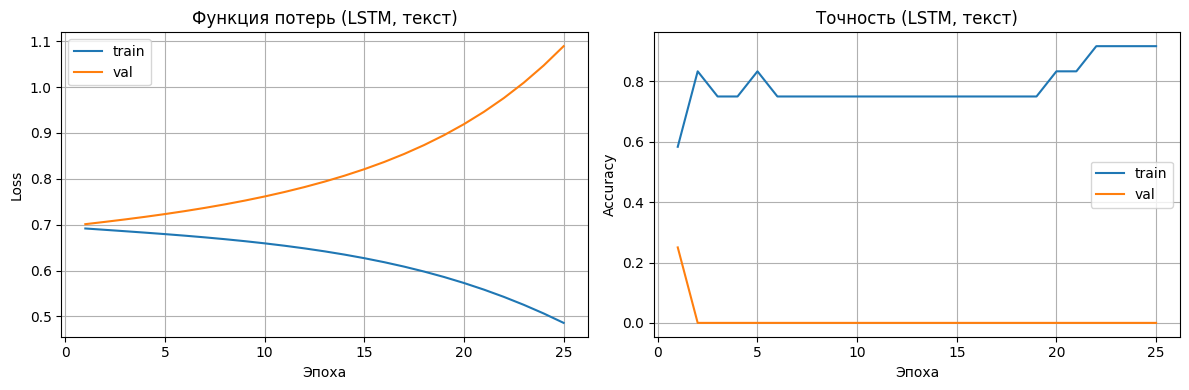

Финальные метрики: train_acc=0.9167, val_acc=0.0000


In [264]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальные метрики: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- что происходит с точностью на **валидации**;
- есть ли заметный разрыв между train и val;
- что вы ожидаете увидеть на реальных данных при тех же настройках.


In [265]:
training_comment = """ЗДЕСЬ ОПИШИТЕ, ЧТО ВЫ УВИДЕЛИ НА ГРАФИКАХ.
Сошлитесь на конкретные значения train/val accuracy, отметьте признаки
переобучения и напишите, что бы вы изменили на реальном датасете.

На графиках видно, что модель переобучилась. Это заметно по огромному разрыву между train_acc=0.9167 и val_acc=0.0000 (реально ноль) в конце обучения.
И loss на валидации постоянно растет, в то время как на обучении падает.
Модель запомнила все примеры и перестала обощать данные, а просто начала наугад тыкать, что хорошо, а что плохо.
Это может быть связано с тем, что нынешний игрушечный датасет слишком маленький и простой.
Думаю, что при тех же настройках на реальном датасете модель справится лучше и даст хотя бы 70-80% точности."""
print(training_comment)

ЗДЕСЬ ОПИШИТЕ, ЧТО ВЫ УВИДЕЛИ НА ГРАФИКАХ.
Сошлитесь на конкретные значения train/val accuracy, отметьте признаки
переобучения и напишите, что бы вы изменили на реальном датасете.

На графиках видно, что модель переобучилась. Это заметно по огромному разрыву между train_acc=0.9167 и val_acc=0.0000 (реально ноль) в конце обучения.
И loss на валидации постоянно растет, в то время как на обучении падает.
Модель запомнила все примеры и перестала обощать данные, а просто начала наугад тыкать, что хорошо, а что плохо.
Это может быть связано с тем, что нынешний игрушечный датасет слишком маленький и простой.
Думаю, что при тех же настройках на реальном датасете модель справится лучше и даст хотя бы 70-80% точности.


## 8. Оценка на тестовой выборке

Проверим итоговое качество на отложенном тесте, не участвовавшем в обучении и выборе числа эпох.


In [266]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=0.8927, accuracy=0.2500


## 9. Примеры предсказаний модели

Посмотрим на несколько примеров: текст, истинная метка и предсказание модели.


In [267]:
model.eval()
idx_to_label = {0: "NEG", 1: "POS"}

def predict_single(text: str):
    tokens = simple_tokenize(text)
    encoded = encode_tokens(tokens, word2idx)
    padded = pad_sequence(encoded, max_len, pad_idx=word2idx["<PAD>"])
    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
    return pred

print("Примеры из тестовой выборки:")
for i in range(min(5, len(X_test))):
    # восстановим текст по токенам (для простоты берём из исходного df)
    # здесь мы знаем, что первые len(X_train) строк относятся к train, остальные к temp
    text_tokens = df.iloc[i]["tokens"]
    text_str = " ".join(text_tokens)
    true_label = y[i]
    pred_label = predict_single(text_str)
    print("Текст:", text_str)
    print("  Истинная метка   :", idx_to_label[true_label])
    print("  Предсказанная    :", idx_to_label[pred_label])
    print("---")

Примеры из тестовой выборки:
Текст: a very ugly and pointless film
  Истинная метка   : NEG
  Предсказанная    : POS
---
Текст: this film was great and inspiring
  Истинная метка   : POS
  Предсказанная    : POS
---
Текст: absolutely disliked the characters
  Истинная метка   : NEG
  Предсказанная    : NEG
---
Текст: a very beautiful and touching film
  Истинная метка   : POS
  Предсказанная    : POS
---


### Комментарий по предсказаниям

Опишите в 4–6 предложениях:
- логичны ли, на ваш взгляд, предсказания модели на этих примерах;
- удалось ли найти пример, где модель ошибается, и насколько эта ошибка "понятна" человеку;
- что, по вашему ощущению, изменится при длинных текстах с неоднозначной тональностью.


In [268]:
pred_comment = """ЗДЕСЬ ОПИШИТЕ СВОИ НАБЛЮДЕНИЯ ПО ПРЕДСКАЗАНИЯМ.
Упомяните хотя бы один пример, где модель оказалась права/неправа,
и как вы это интерпретируете.

Есть отзыв "a very ugly and pointless film", который является негативным, а нейросеть определила его как позитивный.
Скорее всего это из-за схожести с одним из позитивных отзывов "A very beautiful and touching film" (но это лишь предположение).
Очень странно, что здесь модель правильно определила 3 из 4-х отзывов, а лучшая точность была 0.5. Хотя может это совпадение просто."""
print(pred_comment)

ЗДЕСЬ ОПИШИТЕ СВОИ НАБЛЮДЕНИЯ ПО ПРЕДСКАЗАНИЯМ.
Упомяните хотя бы один пример, где модель оказалась права/неправа,
и как вы это интерпретируете.

Есть отзыв "a very ugly and pointless film", который является негативным, а нейросеть определила его как позитивный.
Скорее всего это из-за схожести с одним из позитивных отзывов "A very beautiful and touching film" (но это лишь предположение).
Очень странно, что здесь модель правильно определила 3 из 4-х отзывов, а лучшая точность была 0.5. Хотя может это совпадение просто.


## 10. Идеи для самостоятельных вариаций (для вашей работы со своим датасетом)

В своей версии лабораторной работы вы должны будете:
- взять **реальный** текстовый датасет (отзывы, комментарии, заголовки новостей и т.п.);
- реализовать ту же цепочку: токенизация → словарь → паддинг → LSTM/GRU;
- поэкспериментировать минимум с двумя архитектурами (например, LSTM vs GRU, 1 vs 2 слоя, разный `hidden_dim`/`embed_dim`);
- сравнить результаты по валидaции/тесту и описать найденные закономерности.

Этот ноутбук даёт только пример на упрощённых данных. Ваш основной вклад - перенос идеи на реальную задачу и её качественный анализ.


## Ниже реалзуйте обучение на своём датасете
У вас всё получится! (быстро же всё обучается)

In [269]:
import re
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

MY_SEED = 15
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)


my_df = pd.read_csv("data/reviews.csv", sep=';')

my_df["label"] = pd.to_numeric(my_df["label"], errors="coerce")
my_df = my_df[my_df["label"].isin([0, 1])]
my_df["label"] = my_df["label"].astype(int)

# Место для вашего датасета
my_positive_sentences = my_df[my_df["label"] == 1]["text"].tolist()
my_negative_sentences = my_df[my_df["label"] == 0]["text"].tolist()

my_texts = my_positive_sentences + my_negative_sentences
my_labels = [1] * len(my_positive_sentences) + [0] * len(my_negative_sentences)

my_df = pd.DataFrame({"text": my_texts, "label": my_labels})
my_df = my_df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(my_df.head(10))
print("Размер датасета:", my_df.shape)
print("Распределение классов:\n", my_df["label"].value_counts())




Устройство: cuda
MY_SEED = 15
                                                text  label
0  В целом товар не плохой, но минус в том, что з...      0
1                   I've got wrong colour. it's bad.      0
2  Спасибо огромное.платье супер.....доставка оче...      1
3  Отличная кофточка, трек отслеживался, доставка...      1
4  синтетика, но за такие деньги другого можно бы...      1
5  Шло почти 3 месяца, такую вещь можно купить го...      0
6      доставка быстрая, качество хорошее!!! спасибо      1
7  Товар доставлен поврежденный, продавец отказал...      0
8  футболки не пришли!открыла спор,в течении длит...      0
9  Good merchandise. Delivered goods on time. But...      0
Размер датасета: (60000, 2)
Распределение классов:
 label
0    30000
1    30000
Name: count, dtype: int64


In [278]:
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^а-яА-Яa-zA-Z\s]", " ", text)
    tokens = text.split()
    return tokens

my_df["tokens"] = my_df["text"].apply(simple_tokenize)
print(my_df[["text", "tokens"]].head())

# Подсчёт частот слов и построение словаря
word_counts = {}
for tokens in my_df["tokens"]:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted_words:
    word2idx[w] = len(word2idx)

idx2word = {idx: w for w, idx in word2idx.items()}

print("Размер словаря:", len(word2idx))
print("Первые элементы словаря:", list(word2idx.items())[:10])

def encode_tokens(tokens, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

my_df["encoded"] = my_df["tokens"].apply(lambda t: encode_tokens(t, word2idx))
print(my_df[["tokens", "encoded"]].head())

lengths = my_df["encoded"].apply(len)
print("Мин и макс длины последовательностей:", lengths.min(), lengths.max())
max_len = 50
print("max_len =", max_len)

def pad_sequence(seq, max_len, pad_idx=0):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    else:
        return seq[:max_len]

my_df["padded"] = my_df["encoded"].apply(lambda s: pad_sequence(s, max_len, pad_idx=word2idx["<PAD>"]))
print(my_df[["encoded", "padded"]].head())

                                                text  \
0  В целом товар не плохой, но минус в том, что з...   
1                   I've got wrong colour. it's bad.   
2  Спасибо огромное.платье супер.....доставка оче...   
3  Отличная кофточка, трек отслеживался, доставка...   
4  синтетика, но за такие деньги другого можно бы...   

                                              tokens  
0  [в, целом, товар, не, плохой, но, минус, в, то...  
1            [i, ve, got, wrong, colour, it, s, bad]  
2  [спасибо, огромное, платье, супер, доставка, о...  
3  [отличная, кофточка, трек, отслеживался, доста...  
4  [синтетика, но, за, такие, деньги, другого, мо...  
Размер словаря: 41496
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('не', 2), ('на', 3), ('и', 4), ('в', 5), ('очень', 6), ('но', 7), ('размер', 8), ('что', 9)]
                                              tokens  \
0  [в, целом, товар, не, плохой, но, минус, в, то...   
1            [i, ve, got, wrong, colour, it, s, bad

In [279]:
X = np.stack(my_df["padded"].values)
y = my_df["label"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=MY_SEED, stratify=y_temp
)

print("Размеры:")
print("  train:", X_train.shape)
print("  val  :", X_val.shape)
print("  test :", X_test.shape)

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Размеры:
  train: (36000, 50)
  val  : (12000, 50)
  test : (12000, 50)
Кол-во батчей в train_loader: 1125


In [285]:
vocab_size = len(word2idx)
embed_dim = 32
hidden_dim = 64
num_layers = 1
num_classes = 2

class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # [B, T] -> [B, T, E]
        output, (h_n, c_n) = self.lstm(emb)  # h_n: [L, B, H]
        last_hidden = h_n[-1]                # [B, H] — последнее по времени состояние верхнего слоя
        logits = self.fc(last_hidden)
        return logits

model = SimpleLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

print(model)

SimpleLSTMClassifier(
  (embedding): Embedding(41496, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [286]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.0001


In [280]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)
    
    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


Эпоха 1/10: train_loss=0.6914, train_acc=0.5223, val_loss=0.6847, val_acc=0.5514
Эпоха 2/10: train_loss=0.5082, train_acc=0.7631, val_loss=0.4252, val_acc=0.8063
Эпоха 3/10: train_loss=0.3704, train_acc=0.8438, val_loss=0.3296, val_acc=0.8614
Эпоха 4/10: train_loss=0.3058, train_acc=0.8765, val_loss=0.2900, val_acc=0.8837
Эпоха 5/10: train_loss=0.2726, train_acc=0.8931, val_loss=0.2837, val_acc=0.8897
Эпоха 6/10: train_loss=0.2519, train_acc=0.9029, val_loss=0.2567, val_acc=0.8982
Эпоха 7/10: train_loss=0.2362, train_acc=0.9104, val_loss=0.2468, val_acc=0.9032
Эпоха 8/10: train_loss=0.2222, train_acc=0.9149, val_loss=0.2461, val_acc=0.9061
Эпоха 9/10: train_loss=0.2113, train_acc=0.9214, val_loss=0.2354, val_acc=0.9080
Эпоха 10/10: train_loss=0.2024, train_acc=0.9229, val_loss=0.2281, val_acc=0.9120


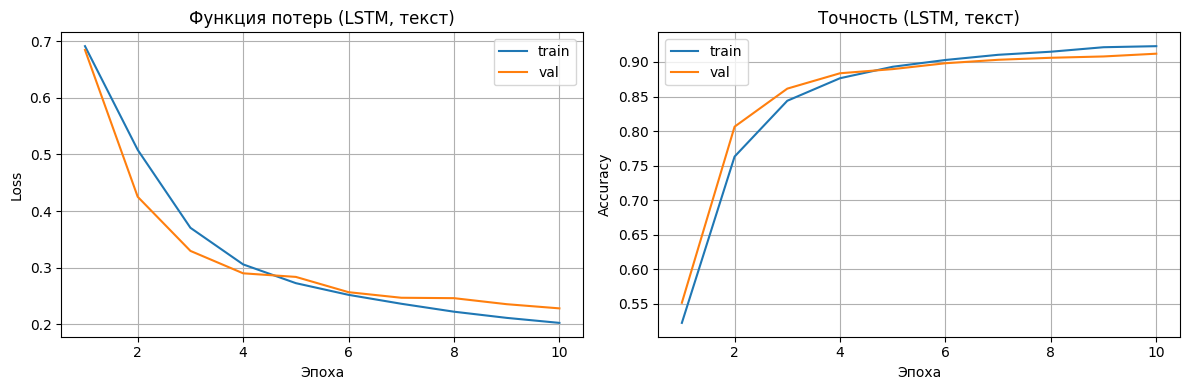

Финальные метрики: train_acc=0.9229, val_acc=0.9120


In [287]:
num_epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальные метрики: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

In [ ]:
final_summary = """ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ ДЛЯ ИТОГОВОГО РЕЗЮМЕ: 
какие архитектуры пробовали,
какие настройки оказались наиболее важными и какие правила вы для себя
сформулировали по настройке RNN для текстов.


В самом начале я пробовал использовать свой собственный датасет. Выбрал товар на Озоне, собрал отзывы и перевел их на английский.
Попробовал запустить - точность стабильно держалась на 0.5, как бы я не менял настроки самой модели и обучения.
Позже понял, что такой датасет тоже ничтожно мал (всего 60 примеров, словарь около 300), как и первоначальный игрушечный.
Явно нужно было собрать больше отзывов, но это такая не то чтобы трудоемкая, а монотонная скучная работа.
Да, может быть это полезно было попробовать самостоятельно, чтобы понимать весь процесс построения датасета для обучения. Но вот так в ручную даже 500 отзывов тяжело обработать (а парсить сайты я пока не научился).
Поэтому я взял датасент с Kaggle с отзывами про одежду (60K примеров). Там есть как английские, так и русские отзывы. Убрал все нейтральные.
Тут уже стало интереснее, потому что точность хотя бы сдвинулась до 0.6 на стандартных настройках.
Менял количество слоев, параметров, оптимизатор (AdamW, SGD, SGD+mome) - точность максимум была val_acc=0.6217, но там кривые были вообще нестабильные.
Поменял количество батчей со 128 на 32, стало гораздо лучше точность выросла до 0.9201, но было замечено переобучение (val_loss начал расти после 8 эпохи, и разрыв между train_acc и val_acc увеличивался).
В итоге модель оказалась чувствительной к learning_rate вместо 1е-3, сделал 1е-4 - кривые стали стабильными, loss постоянно падал, а точность росла до val_acc=0.9120."""
print(final_summary)

ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ ДЛЯ ИТОГОВОГО РЕЗЮМЕ: 
какие архитектуры пробовали,
какие настройки оказались наиболее важными и какие правила вы для себя
сформулировали по настройке RNN для текстов.
